In [1]:
import torch
import os
import random
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
from torchvision.utils import make_grid
#from modules_energy_score_xinwei import StoNet
from engression.models import StoNet, StoLayer
#from loss_func import energy_loss_two_sample
from engression.loss_func import energy_loss_two_sample
import argparse
import json
import xarray as xr
import torch.nn as nn

#from utils_cordex_v2 import get_data_cordex_v2
#from utils_cordex_v4 import get_data_cordex_v3
#from config import get_config
#from utils import *
#from models_cnn import cGenerator
import sys
#sys.path.append("..")

In [2]:
def standardize_numpy(X):
    mean = X.mean(axis=0, keepdims=True)
    std = X.std(axis=0, keepdims=True)
    return (X - mean) / (std), mean, std
    
def visual_sample(model_enc, model_dec, model_pred, x, y, save_dir, to_img=True):
    model_enc.eval()
    model_dec.eval()
    model_pred.eval()
    with torch.no_grad():
        # gen = model(x).detach().cpu()#.view(x.shape[0], 1, 128, 128)
        rec1 = model_dec(model_enc(y)).detach().cpu()
        rec2 = model_dec(model_enc(y)).detach().cpu()
            
        gen1 = model_dec(model_pred(x)).detach().cpu()
        gen2 = model_dec(model_pred(x)).detach().cpu()
    if to_img:
        rec1 = rec1.view(x.shape[0], 1, 128, 128)
        rec2 = rec2.view(x.shape[0], 1, 128, 128)
        gen1 = gen1.view(x.shape[0], 1, 128, 128)
        gen2 = gen2.view(x.shape[0], 1, 128, 128)
        y = y.view(y.shape[0], 1, 128, 128)
    # y = y.cpu().view(y.shape[0], 1, 128, 128)
    sample = torch.cat([y.cpu(), rec1, rec2, gen1, gen2])
    sample = torch.clamp(sample, torch.quantile(y, 0.005).item(), torch.quantile(y, 0.995).item())
    plt.matshow(make_grid(sample, nrow=y.shape[0]).permute(1, 2, 0)[:,:,0], cmap="Spectral_r"); plt.axis('off'); 
    plt.savefig(save_dir, bbox_inches="tight", pad_inches=0, dpi=300); plt.close()
    # save_image(sample, save_dir, normalize=True, scale_each=True)
    model_enc.train()
    model_dec.train()
    model_pred.train()

def data_to_torch(ds, variable):
    temp_data = ds[variable]
    data = temp_data.transpose('time', 'lat', 'lon')
    
    # Now convert to numpy
    data_np = data.values  # Shape: (time, lat, lon)
    
    # Flatten lat and lon together
    time_steps, lat_dim, lon_dim = data_np.shape
    data_np = data_np.reshape(time_steps, lat_dim * lon_dim)
    
    
    data_np = data_np  # Shape: (grid_cell, timestep)
    
    # Finally, convert to torch tensor
    data_tensor = torch.tensor(data_np, dtype=torch.float32)
    print(data_tensor.shape)
    return data_tensor

def predictors_to_torch(ds, variable):
    temp_data = ds#[variable]
    data = temp_data.transpose('time', 'mode')
    
    # Now convert to numpy
    data_np = data.values  # Shape: (time, lat, lon)

    
    # Flatten lat and lon together
    #time_steps, lat_dim, lon_dim = data_np.shape
    #data_np = data_np.reshape(time_steps, lat_dim * lon_dim)
    
    
    #data_np = data_np  # Shape: (grid_cell, timestep)
    
    # Finally, convert to torch tensor
    data_tensor = torch.tensor(data_np, dtype=torch.float32)
    print(data_tensor.shape)
    return data_tensor

In [3]:
#if __name__ == '__main__':

#args = get_config()

random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed(42)

#device = torch.device('cuda')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

#if args.cnn:
#    save_dir = f'results/eng/nm{args.n_models}/cnn_lat{args.latent_dim}'
#else:
#    save_dir = f"results/{args.method}/nm{args.n_models}_un/layer{args.num_layer}_hidden{args.hidden_dim}_noise{args.noise_dim}{args.save_name}/"

save_dir = "joint_low_level_out"
#make_folder(save_dir)
#write_config_to_file(args, save_dir)

device: cuda


In [4]:
#### load data

#train_loader, test_loader_in, test_loader_out = get_data_cordex_v3(args.n_models, variables = args.variables)
#print('#training batches:', len(train_loader))
#x_tr_eval, y_tr_eval = data2pair(next(iter(train_loader)), n=args.n_visual, device=device, keep_img=args.cnn, rank = args.rank)
#x_te_eval, y_te_eval = data2pair(next(iter(test_loader_in)), n=args.n_visual, device=device, keep_img=args.cnn, rank = args.rank)

# read contents from the settings.json file
settings_file_path = 'dpa_train_settings.json'

with open(settings_file_path, 'r') as file:
    settings = json.load(file)


# Create directories
#os.makedirs(output_dir, exist_ok=True)    

# Save to a new file for logging
with open(f"{save_dir}/used_settings.json", "w") as f:
    json.dump(settings, f, indent=4)

# load my temperature data
# Load your NetCDF file
ds = xr.open_dataset(settings['dataset_trefht'])

ds_train = ds.isel(time=slice(0, 128000)) #4769 * 80
ds_test = ds.isel(time=slice(-64000, 476900)) #4769 * 80

# transform to torch tensors
x_tr = data_to_torch(ds_train, "TREFHT")
x_te = data_to_torch(ds_test, "TREFHT")

# load Z500
ds_z500_pre = xr.open_dataset(settings['dataset_z500'])
ds_z500, _, _ = standardize_numpy(ds_z500_pre.pseudo_pcs.values)
print("z500 shape", ds_z500.shape)
z500 = torch.from_numpy(ds_z500) #predictors_to_torch(ds_z500, "pseudo_pcs")
print("z500 shape", z500.shape)
# scale Z500


z500_train = z500[:128000,:]#[:381520,:]
z500_test = z500[-64000:,:]

torch.Size([128000, 1024])
torch.Size([64000, 1024])
z500 shape (476900, 1000)
z500 shape torch.Size([476900, 1000])


In [5]:
#### build model
#if args.method == 'eng':
    #if args.cnn:
    #    model = cGenerator(args.latent_dim, args.g_conv_dim, args.image_size, out_channels=1, tanh=False, add_noise=True,
    #                        cond_dim=x_tr_eval.shape[1], prior_num_layer=args.prior_layer, prior_hidden_dim=args.prior_fc_size,
    #                        prior_dist=args.prior, latent_noise_dim=args.latent_noise_dim).to(device)
    #else:
in_dim = 1024
latent_dim = 20
num_layers = 6
hidden_dim = 100
noise_dim = 20
bn = False
resblock = True
noise_std = 1
out_act=None
noise_dim_dec=20
lr = 1e-4



In [6]:
# prepare data
from torch.utils.data import TensorDataset, DataLoader

batch_size = 128 #190
# create data loader Temperature
train_dataset = TensorDataset(x_tr, x_tr)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
print(f"Number of batches: {len(train_loader)}")

# create data loader Z500
train_dataset_z500 = TensorDataset(z500_train)
train_loader_z500 = DataLoader(train_dataset_z500, batch_size=batch_size, shuffle=True)
print(f"Number of batches: {len(train_loader_z500)}")

# create test loader Temperature
test_dataset = TensorDataset(x_te, x_te)
test_loader_in = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
print(f"Number of batches: {len(test_loader_in)}")

# create test data loader Z500
dataset_z500_test = TensorDataset(z500_test)
test_loader_z500 = DataLoader(dataset_z500_test, batch_size=batch_size, shuffle=False)
print(f"Number of batches: {len(test_loader_z500)}")


Number of batches: 1000
Number of batches: 1000
Number of batches: 500
Number of batches: 500


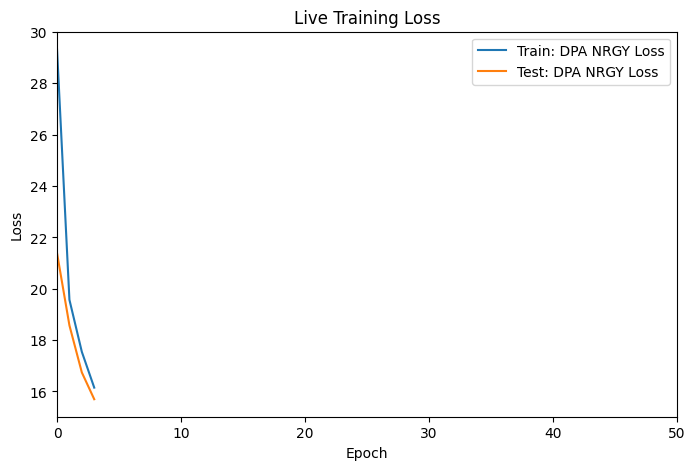

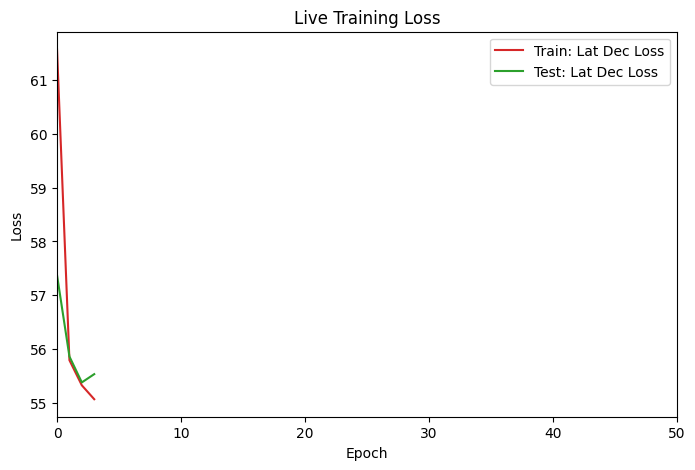

e: tensor([  9.8704, -12.1432,   6.5312, -15.0906, -25.4033,  -3.3508,  -9.1912,
         16.2039, -14.3903,  10.2005,  -9.2016,  11.6089,   8.2264,   2.7641,
          9.6388,  12.8213, -13.4085,   6.9677,   0.1080,   4.0772],
       device='cuda:0', grad_fn=<SliceBackward0>)
z1: tensor([-1.9643,  3.7868, -1.8532, -1.9215, -2.0935,  0.4771, -2.9292,  2.6824,
         2.5026,  0.5897, -2.7135, -1.2113, -0.8520,  2.7001,  2.7515, -2.0180,
         0.4560,  2.6913,  2.4263,  3.8471], device='cuda:0',
       grad_fn=<SliceBackward0>)
e: tensor([  0.5378,  -5.1626,   8.6399,  -7.6668, -12.2330,   2.0948,  -6.1330,
          2.4614,  -8.0446,   2.6157,  -1.7786,   7.6156,   7.0915,   1.3586,
          4.8367,   4.5472,  -5.2765,   0.6747,   1.8019,  13.4546],
       device='cuda:0', grad_fn=<SliceBackward0>)
z1: tensor([-3.0147,  5.8774, -3.6134, -2.8948, -3.2877,  0.3881, -4.6056,  2.5383,
         2.7505,  1.1715, -4.9583, -2.0336, -0.0966,  3.1362,  3.8455, -2.4307,
         1.1474,  5.0

In [ ]:
# Encoder
model_enc = StoNet(in_dim=in_dim,
                   out_dim=latent_dim,
                   num_layer=num_layers,
                   hidden_dim=hidden_dim,
                   noise_dim=0,
                   add_bn=bn,
                   out_act=out_act,
                   resblock=resblock).to(device)
# Decoder
model_dec = StoNet(in_dim=latent_dim,
                   out_dim=in_dim,
                   num_layer=num_layers,
                   hidden_dim=hidden_dim,
                   noise_dim=noise_dim_dec,
                   add_bn=bn,
                   out_act=out_act,
                   resblock=resblock).to(device)

model_pred = StoNet(1000, latent_dim, num_layer=4, hidden_dim = hidden_dim, noise_dim = noise_dim,
                            add_bn=bn, out_act=out_act, resblock=resblock).to(device)


optimizer = torch.optim.Adam(list(model_enc.parameters()) + list(model_dec.parameters()) + list(model_pred.parameters()), lr=lr)
#epochs = 20
# data
beta = 1
loss_fn = nn.MSELoss()
print_every_nepoch = 1
save_model_every = 100
losses_dpa_only_list_tr=[]
losses_dpa_only_list_te=[]

losses_lin_lat_pred_tr = []
losses_lin_lat_pred_te = []

losses_s1_lat_dec_tr = []
losses_s2_lat_dec_tr = []
losses_s1_lat_dec_te = []
losses_s2_lat_dec_te = []
losses_kl = []

training_epochs = 50
epochs_list=[]

log_file_name = os.path.join(save_dir, 'log_neural_latent_map.txt')

#if args.resume_epoch > 0:
#    log_file = open(log_file_name, "at")
#else:
log_file = open(log_file_name, "wt")
    
for epoch_idx in range(0, training_epochs):
    #if epoch_idx == args.resume_epoch:
    #    print('Training has started!')
    loss_tr_tot = 0
    loss_tr_dpa_only = 0
    loss_tr_lat_dec = 0

    loss_te_tot = 0
    loss_te_dpa_only = 0
    loss_te_lat_dec = 0

    
    #loss_tr_pred = 0
    #s1_tr = 0
    #s1_tr_pred = 0
    #s2_tr = 0
    #s2_tr_pred = 0
    for batch_idx, (data_batch, slp_batch) in enumerate(zip(train_loader, train_loader_z500)):
        optimizer.zero_grad()
        #x, y = data2pair(data_batch, device=device, rank=args.rank)
        x = slp_batch[0].to(device)
        y = data_batch[0].to(device)

        
        e = model_enc(y)
        rec1 = model_dec(e) 
        rec2 = model_dec(e)
        print("e:", e[0,:])
        z1 = model_pred(x)
        gen1 = model_dec(z1)
        z2 = model_pred(x)
        gen2 = model_dec(z2)
        print("z1:", z1[0,:])
        
        
        loss_rec, s1_rec, s2_rec = energy_loss_two_sample(y, rec1, rec2, verbose=True, beta=beta)
        
        loss = loss_rec
        
        #if True:#args.loss_eval_latent:
        #    loss_pred, s1_pred, s2_pred = energy_loss_two_sample(e, z1, z2, verbose=True, beta=args.beta) #loss im latent space
        #    loss = loss + loss_pred
        #    penalty_e = torch.linalg.vector_norm(e.std(dim=0) - 1) + torch.linalg.vector_norm(e.mean(dim=0)) # penalizes deviations from std=1 and mean = 0 for encoded sample 
        #    penalty_gen = torch.linalg.vector_norm(z1.std(dim=0) - 1) + torch.linalg.vector_norm(z1.mean(dim=0)) # penalizes deviations from std=1 and mean = 0 for predicted latent sample
        #    loss = loss + penalty_e + penalty_gen
        #else:
        loss_pred, s1_pred, s2_pred = energy_loss_two_sample(y, gen1, gen2, verbose=True, beta=beta)
        loss = loss + loss_pred
            
        loss.backward()
        optimizer.step()
        
        loss_tr_tot += loss.item()
        loss_tr_dpa_only += loss_rec.item()
        loss_tr_lat_dec += loss_pred.item()
        #s1_tr += s1_rec.item() + s1_pred.item()
        #s2_tr += s2_rec.item() + s2_pred.item()
        
        #loss_tr_pred += loss_pred.item()
        #s1_tr_pred += s1_pred.item()            
        #s2_tr_pred += s2_pred.item()
        
    if (epoch_idx == 0 or (epoch_idx + 1) % print_every_nepoch == 0):
        #log = f'[Epoch {epoch_idx + 1}]\tloss: {loss_tr / len(train_loader):.4f}, s1: {s1_tr / len(train_loader):.4f}, s2: {s2_tr / len(train_loader):.4f}'
        
        if epoch_idx == 0 or ((epoch_idx + 1) % (print_every_nepoch) == 0):
            model_enc.eval()
            model_dec.eval()
            model_pred.eval()
            loss_te_tot = 0; loss_te_dpa_only = 0; loss_te_lat_dec=0 #s1_te = 0; s2_te = 0
            with torch.no_grad():
                #for data_te in test_loader_in:
                for (test_batch, slp_test_batch) in zip(test_loader_in, test_loader_z500):
                    #x_te, y_te = data2pair(data_te, device=device, rank=args.rank
                    y_te = test_batch[0].to(device)
                    x_te = slp_test_batch[0].to(device)
                    
                    rec1_te = model_dec(model_enc(y_te))
                    rec2_te = model_dec(model_enc(y_te))
                    
                    gen1_te = model_dec(model_pred(x_te))
                    gen2_te = model_dec(model_pred(x_te))

                    loss_dpa_test = energy_loss_two_sample(y_te, rec1_te, rec2_te, beta=beta)[0].item()
                    loss_lat_dec_test = energy_loss_two_sample(y_te, gen1_te, gen2_te, beta=beta)[0].item()
                    
                    
                    loss_te_dpa_only += loss_dpa_test
                    loss_te_lat_dec += loss_lat_dec_test
                    loss_te_tot += loss_te_dpa_only + loss_te_lat_dec
                    
                    #loss_te += energy_loss_two_sample(y_te, rec1_te, rec2_te, beta=args.beta).item()
                    #loss_te += energy_loss_two_sample(y_te, gen1_te, gen2_te, beta=args.beta).item()
                    
                    #s1_te += s1_rec.item() + s1_pred.item() 
                    #s2_te += s2_rec.item() + s2_pred.item()
                    
            #log += f'\n  Test  \tloss: {loss_te / len(test_loader_in):.4f}, s1: {s1_te / len(test_loader_in):.4f}, s2: {s2_te / len(test_loader_in):.4f}'
            model_enc.train()
            model_dec.train()
            model_pred.train()
        
        #print(log)
        #log_file.write(log + '\n')
        #log_file.flush()
    
    #if (epoch_idx == 0 or (epoch_idx + 1) % args.sample_every_nepoch == 0):
    #    
    #    visual_sample(model_enc, model_dec, model_pred, x_tr_eval, y_tr_eval, save_dir=save_dir + f'img_{epoch_idx + 1}_tr.png', to_img=~args.cnn)
    #    visual_sample(model_enc, model_dec, model_pred, x_te_eval, y_te_eval, save_dir=save_dir + f'img_{epoch_idx + 1}_te.png', to_img=~args.cnn)
    
    #if (epoch_idx + 1) % args.save_model_every == 0:# and i >= 30:
    #    torch.save(model_enc.state_dict(), save_dir + "model_enc_" + str(epoch_idx + 1) + ".pt")
    #    torch.save(model_dec.state_dict(), save_dir + "model_dec_" + str(epoch_idx + 1) + ".pt")
    #    torch.save(model_pred.state_dict(), save_dir + "model_pred_" + str(epoch_idx + 1) + ".pt")


    losses_dpa_only_list_tr.append(loss_tr_dpa_only / len(train_loader))
    losses_dpa_only_list_te.append(loss_te_dpa_only / len(test_loader_in))
    
    losses_lin_lat_pred_tr.append(loss_tr_lat_dec / len(train_loader))
    losses_lin_lat_pred_te.append(loss_te_lat_dec / len(test_loader_in))
    
    # 🔁 Dynamic plot
    clear_output(wait=True)
    plt.figure(figsize=(8, 5))
    plt.plot(losses_dpa_only_list_tr, label="Train: DPA NRGY Loss", color='tab:blue')
    plt.plot(losses_dpa_only_list_te, label="Test: DPA NRGY Loss", color='tab:orange')
    
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Live Training Loss")
    plt.legend()
    #plt.grid(True)
    #plt.ylim(0,30)
    #plt.xticks(ticks=range(0, training_epochs, 1))
    plt.xlim(0,training_epochs)
    plt.show()
    ###########################################################################
    plt.figure(figsize=(8, 5))
    plt.plot(losses_lin_lat_pred_tr, label="Train: Lat Dec Loss", color='tab:red')
    plt.plot(losses_lin_lat_pred_te, label="Test: Lat Dec Loss", color='tab:green')
    
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Live Training Loss")
    plt.legend()
    #plt.grid(True)
    #plt.ylim(0,30)
    #plt.xticks(ticks=range(0, training_epochs, 1))
    plt.xlim(0,training_epochs)
    plt.show()